In [22]:
!python3 -m pip install --upgrade pip


In [23]:
!python3 -m pip install numpy==1.26.4 scipy==1.11.4 matplotlib librosa==0.10.1 soundfile numba==0.59.1 llvmlite==0.42.0


In [24]:
import librosa
import numba
import numpy
import matplotlib
import soundfile

print("🎉 All audio libraries are working perfectly!")


🎉 All audio libraries are working perfectly!


In [25]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import IPython.display as ipd
import numpy as np


In [26]:
import os
print(os.getcwd())


/Users/varshini/Desktop/BabyCryAIProject


In [33]:
print(os.listdir())


['.DS_Store', 'README.md', 'data (Audio Files)', '.gitignore', '.ipynb_checkpoints', 'Baby_Cry_Translator.ipynb', 'BabyCryApp', '.git', 'retrain_model.py']


In [39]:
print(os.listdir("./data (Audio Files)"))



['.DS_Store', 'bellypain', 'discomfort', 'burping', 'scared', 'sample.wav', 'sleepy', 'hunger']


In [40]:
audio_path = "data (Audio Files)/sample.wav"


In [41]:
signal, sample_rate = librosa.load(audio_path, sr=None)

print("Loaded successfully!")
print("Sample rate:", sample_rate)
print("Duration:", len(signal)/sample_rate)


Loaded successfully!
Sample rate: 8000
Duration: 7.0


In [43]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Load audio
audio_path = "data (Audio Files)/sample.wav"   # keep this if it already worked
signal, sr = librosa.load(audio_path, sr=None)

# Extract MFCC
mfcc = librosa.feature.mfcc(
    y=signal,
    sr=sr,
    n_mfcc=13
)

print("MFCC shape:", mfcc.shape)


MFCC shape: (13, 110)


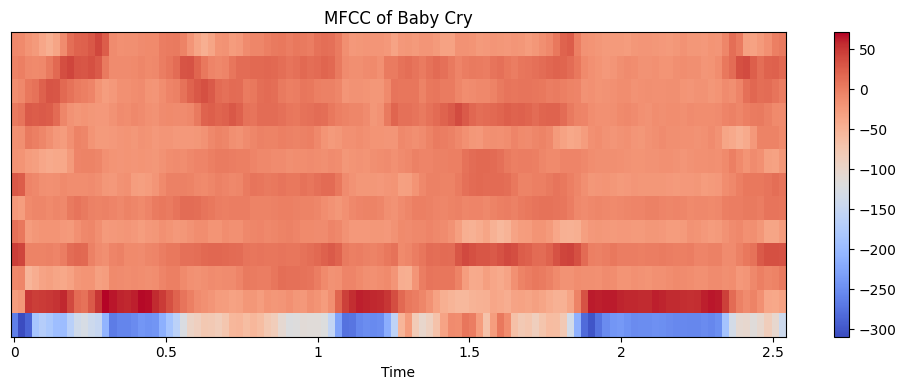

In [44]:
plt.figure(figsize=(10, 4))
librosa.display.specshow(mfcc, x_axis='time')
plt.colorbar()
plt.title("MFCC of Baby Cry")
plt.tight_layout()
plt.show()


In [45]:
mfcc_mean = np.mean(mfcc, axis=1)

print("MFCC feature vector shape:", mfcc_mean.shape)
print(mfcc_mean)


MFCC feature vector shape: (13,)
[-154.43283     11.231325   -13.449755     9.656164   -20.805231
   -3.6443393   -7.419709   -11.647964   -15.410446     1.8504966
   -2.5246563    3.9637134  -13.36705  ]


In [46]:
import os
import numpy as np
import librosa

DATA_PATH = "data (Audio Files)"
labels = ["hunger", "scared", "sleepy", "discomfort","burping", "bellypain"]

X = []
y = []

def extract_features(file_path):
    signal, sr = librosa.load(file_path, sr=None)
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
    return np.mean(mfcc, axis=1)

for label in labels:
    folder_path = os.path.join(DATA_PATH, label)
    for file in os.listdir(folder_path):
        if file.endswith(".wav"):
            file_path = os.path.join(folder_path, file)
            features = extract_features(file_path)
            X.append(features)
            y.append(label)

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape)
print("Labels shape:", y.shape)


Dataset shape: (95, 13)
Labels shape: (95,)


In [48]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print("Encoded labels:", y_encoded)


Encoded labels: [3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 4 4 4 4 4 5 5 5 5 5 5 5 5 5 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)


Training samples: (76, 13)
Testing samples: (19, 13)


In [50]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed!")


Model training completed!


In [51]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nDetailed Report:\n")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))


Accuracy: 0.631578947368421

Detailed Report:

              precision    recall  f1-score   support

   bellypain       0.50      0.50      0.50         2
     burping       0.50      0.25      0.33         4
  discomfort       0.43      0.60      0.50         5
      hunger       0.83      1.00      0.91         5
      scared       0.00      0.00      0.00         1
      sleepy       1.00      1.00      1.00         2

    accuracy                           0.63        19
   macro avg       0.54      0.56      0.54        19
weighted avg       0.60      0.63      0.60        19



/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [52]:
def predict_cry(audio_path):
    features = extract_features(audio_path)
    features = features.reshape(1, -1)

    prediction = model.predict(features)
    label = encoder.inverse_transform(prediction)

    return label[0]


In [56]:
result = predict_cry("data (Audio Files)/sample.wav")
print("Baby is crying due to:", result)


Baby is crying due to: burping


In [57]:
print(model)
print(encoder)


RandomForestClassifier(n_estimators=200, random_state=42)
LabelEncoder()


In [58]:
# ===== Imports =====
import os
import librosa
import numpy as np
import pandas as pd
import pickle

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


In [59]:
!pip install pandas


In [60]:
import pandas as pd


In [61]:
import pandas as pd
print(pd.__version__)


2.3.3


In [62]:
import os
import librosa
import numpy as np
import pandas as pd
import pickle


In [63]:
import os

DATASET_PATH = "data (Audio Files)"

print("Folders inside data:")
print(os.listdir(DATASET_PATH))


Folders inside data:
['.DS_Store', 'bellypain', 'discomfort', 'burping', 'scared', 'sample.wav', 'sleepy', 'hunger']


In [64]:
import librosa
import numpy as np

def extract_features(file_path):
    audio, sr = librosa.load(file_path, sr=None)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    return np.mean(mfcc.T, axis=0)


In [65]:
import os
import pandas as pd

X = []
y = []

for label in os.listdir("data (Audio Files)"):
    label_path = os.path.join("data (Audio Files)", label)
    if not os.path.isdir(label_path):
        continue

    for file in os.listdir(label_path):
        if file.endswith(".wav"):
            file_path = os.path.join(label_path, file)
            features = extract_features(file_path)
            X.append(features)
            y.append(label)

print("Total samples:", len(X))


Total samples: 95


In [66]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print("Classes:", encoder.classes_)


Classes: ['bellypain' 'burping' 'discomfort' 'hunger' 'scared' 'sleepy']


In [67]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = np.array(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

print("Training completed")


Training completed


In [68]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)

print("Model & Encoder saved")


Model & Encoder saved
